
⸻

1️⃣ 오프닝 (5~10분)
	•	목표 소개:
	•	“오늘은 노래 가사를 분석해, 검색창에 가사를 입력하면 관련 노래를 찾아주는 간단한 검색 엔진을 만들어볼 거예요.”
	•	핵심 개념 미리 언급:
	•	텍스트 데이터 전처리
	•	BOW vs TF-IDF
	•	검색(query)와 코사인 유사도

⸻

2️⃣ 데이터 탐색 (10분)
	•	songs.csv를 로드하고 head(), info()를 직접 보여주기
	•	가사 데이터의 특징 설명
	•	한글/영어 혼합
	•	불용어 존재
	•	명사만 추출해야 의미 있는 검색이 가능
	•	활동: 참가자에게 1~2곡 데이터 직접 열어보게 하기

⸻

3️⃣ 텍스트 전처리 (20분)
	1.	불용어 제거
	•	preprocess_text() 코드 설명
	•	불필요한 조사/대명사가 검색 품질을 떨어뜨리는 이유 설명
	•	실습: 참가자가 직접 불용어 리스트에 단어 추가해보기
	2.	형태소 분석 & 명사 추출
	•	Kiwi로 형태소 분석 → 명사만 추출하는 이유 설명
	•	실습: "사랑해 너를 너무나" → ['사랑', '너무'] 변환 과정 직접 확인

⸻

4️⃣ Bag of Words & TF-IDF 이해 (30분)
	•	BOW: 단순 단어 빈도 기반 벡터
	•	create_bow() 함수 출력 보여주며, 단어 순서 정보가 사라진다는 점 강조
	•	TF-IDF: 중요 단어에 가중치 부여
	•	희귀 단어가 높은 점수 → 검색 품질 향상
	•	tfidf_vectorizer.fit_transform() 결과 shape 확인

🔹 시각화 활동:
	•	WordCloud 실행 → 가사 데이터에서 가장 많이 등장하는 단어 시각화
	•	참가자에게 특정 가사에서 단어별 TF-IDF 점수를 계산하게 해보기

⸻

5️⃣ 검색 엔진 구현 (20분)
	1.	SimpleSearchEngine 클래스 구조 설명
	•	쿼리 전처리 → TF-IDF 변환 → 코사인 유사도 계산 → 상위 결과 반환
	2.	'사랑'으로 검색 실습
	•	결과에서 similarity가 어떻게 달라지는지 확인
	3.	참가자가 직접 "이별", "밤하늘" 같은 다른 쿼리 테스트

⸻

6️⃣ 마무리 & 확장 아이디어 (10분)
	•	검색 품질을 높이는 방법
	•	불용어 사전 확장
	•	BERT 기반 검색으로 확장 (문맥 의미까지 반영)
	•	검색 결과 하이라이트 표시 기능
	•	Q&A 세션
	•	TF-IDF와 구글 검색의 기본 원리 연관성 설명

⸻

📌 수업 핵심 포인트
	•	실습 → 즉시 결과 확인 → 개념 연결
	•	TF-IDF가 검색어에서 어떻게 작동하는지 직접 눈으로 확인하게 함
	•	참가자가 불용어/쿼리를 바꿔보면서 검색 품질 변화를 체험하도록 유도

⸻

TF-IDF에 대해 알아보자

NLP에 대해 알아보자\
텍스트 데이터의 특성\
BOW (Bag of Words)

미니 검색어 엔진 만들기 -> 요거 가자

In [ ]:
# ! pip install kiwipiepy
# ! pip install wordcloud

In [ ]:
# -*- coding: utf-8 -*-
# NLP 튜토리얼 - 노래 가사 분석 및 검색 엔진 만들기

# 1. 필요한 라이브러리 임포트
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import re

In [ ]:
# 불용어 리스트 정의
def load_stopwords():
    # 기본 불용어 리스트
    stopwords = [
        '은', '는', '이', '가', '을', '를', '에', '에서', '의', '로', '으로', '와', '과', '도', '만', '까지',
        '에서', '에게', '하고', '이다', '있다', '없다', '같다', '있다', '그', '저', '이', '것', '수', '등', '들',
        '때', '한', '지', '하', '오', '말', '일', '때문', '거', '게', '너무', '더', '나', '내', '걸', '이런',
        '저런', '왜', '그냥', '다시', '정도', '때문', '이제', '다시', '모두', '아니', '없이', '같이', '처럼',
        '다른', '모든', '우리', '내가', '네가', '그녀', '그들', '나의', '너의', '이것', '저것', '그것', '누구',
        '무엇', '어디', '언제', '어떻게', '왜', '몇', '얼마나', '모든', '다른', '어떤', '무슨', '아무', '이런',
        '저런', '그런', '무슨', '아무', '이런', '저런', '그런', '무슨', '아무', '이런', '저런', '그런', '무슨', '아무',
        'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll",
        "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's",
        'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves',
        'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was',
        'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an',
        'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with',
        'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to',
        'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once',
        'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most',
        'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 's',
        't', 'can', 'will', 'just', 'don', "don't", 'should', "should've", 'now', 'd', 'll', 'm', 'o', 're',
        've', 'y', 'ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't",
        'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't",
        'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't",
        'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"
    ]
    return set(stopwords)


In [15]:

# 2. 데이터 로드 및 탐색
print("1. 데이터 로드 중...")
df = pd.read_csv('songs.csv')
print("\n데이터 샘플:")
print(df.head())
print("\n데이터 정보:")
df.info()


1. 데이터 로드 중...

데이터 샘플:
        title                   artist   song_id  \
0      Golden                  HUNTR/X  39166708   
1    Soda Pop  KPop Demon Hunters Cast  39166705   
2      FAMOUS           ALLDAY PROJECT  39156202   
3    뛰어(JUMP)                BLACKPINK  39298775   
4  Dirty Work                    aespa  39121279   

                                              lyrics  
0  I was a ghost, I was alone, hah\n어두워진, hah, 앞길...  
1  Hey, hey\nHey, hey\nHey\nDon't want you, need ...  
2  분명 나쁜 아이는 아니어도\n또 틀에 가두면 we break it\nBum no b...  
3  I’m not that easy to tame\nYou should see me u...  
4  World domination\nI don’t gotta say it\n전엔 없던\...  

데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    30 non-null     object
 1   artist   30 non-null     object
 2   song_id  30 non-null     int64 
 3   lyrics   30 non-null     object


In [ ]:
# 3. 텍스트 데이터 전처리
def preprocess_text(text, remove_stopwords=True):
    # 한글, 영어, 공백만 남기고 제거
    text = re.sub(r'[^가-힣a-zA-Z\s]', ' ', str(text))
    
    # 불용어 제거
    if remove_stopwords:
        stopwords = load_stopwords()
        words = text.split()
        words = [word for word in words if word not in stopwords]
        text = ' '.join(words)
    
    return text.strip()

print("\n2. 텍스트 전처리 중...")
# 불용어 제거를 포함한 텍스트 전처리
df['cleaned_lyrics'] = df['lyrics'].apply(lambda x: preprocess_text(x, remove_stopwords=True))


2. 텍스트 전처리 중...


In [17]:
from kiwipiepy import Kiwi

# 1️⃣ 형태소 분석기 초기화
tokenizer = Kiwi()

# 2️⃣ 명사 추출 함수 정의
def get_nouns(text, min_length=1):
    tokens = tokenizer.tokenize(text)  # 형태소 분석
    nouns = [token.form for token in tokens if token.tag.startswith('N')]  # 'N'으로 시작하는 품사만
    return ' '.join([noun for noun in nouns if len(noun) >= min_length])

# 3️⃣ DataFrame에 적용
print("\n3. 명사 추출 중...")
df['nouns'] = df['cleaned_lyrics'].apply(lambda x: get_nouns(x, min_length=2))

df['nouns']


3. 명사 추출 중...


0                                                 앞길 우리
1                                           당장 시간 모금 소름
2     아이 무대 서면 시선 단위 느껴져 분위기 이름 아이 무대 서면 시선 뿌리 초록 빛깔...
3                         착각 누구 누구 하나 뛰어 순간 누구 누구 하나 뛰어
4                          돌연변이 저주 다수 오답 정답 선택 따위 번뇌 음률
5                                  사랑 여기 다정 이곳 눈물 사랑 어디
6     존재 이유 바람 이유 세계 시계 붕괴 세상 찰나 시작 시간 중력 우리 이야기 시작 ...
7     햇살 소리 바람 한숨 눈물 이름 내일 미래 라인 천진난만 기분 정도 사랑 시간 처음...
8                                     황홀 존재 아이 순간 황홀 황홀
9     찬바람 그대 생각 인사 그리움 가슴속 수천 그대 대답 계절 소리 대여 눈물 이별 가...
10    집중 이유 이해 무리 어디 집중 이유 이해 무리 하나 외면 시작 순간 판단 기회 집...
11                          아무 관심 신경 순간 허세 여기 나쁠래 목숨 세계
12    소낙비 모습 어제 오늘 아침 햇살 어젯밤 눈물 거울 모습 거울 지금 실감 어제 사랑...
13                          얼마 서커스 셀럽 바비 처키 제니 예술 작품 필요
14    오랜만 노래 혼비백산 해진 장세 도레미 파시 두껍아 두껍아 삼계탕 하나 팀워크 무대...
15                                             뼈속 앞길 포기
16      어디 오늘 의자 모습 바람 추억 영화 시절 그대 추억 영화 시절 그대 영화 시절 그대
17    우리 나이 우리 확신 우리 꽃말 라일락 영원 시간 청춘 어제 출발선 무모 공

In [18]:
df

,title,artist,song_id,lyrics,cleaned_lyrics,nouns
0,Golden,HUNTR/X,39166708,"I was a ghost, I was alone, hah\n어두워진, hah, 앞길...",I ghost I alone hah 어두워진 hah 앞길속에 Ah Given thr...,앞길 우리
1,Soda Pop,KPop Demon Hunters Cast,39166705,"Hey, hey\nHey, hey\nHey\nDon't want you, need ...",Hey hey Hey hey Hey Don want need Yeah I need ...,당장 시간 모금 소름
2,FAMOUS,ALLDAY PROJECT,39156202,분명 나쁜 아이는 아니어도\n또 틀에 가두면 we break it\nBum no b...,분명 나쁜 아이는 아니어도 또 틀에 가두면 break Bum bigger girl ...,아이 무대 서면 시선 단위 느껴져 분위기 이름 아이 무대 서면 시선 뿌리 초록 빛깔...
3,뛰어(JUMP),BLACKPINK,39298775,I’m not that easy to tame\nYou should see me u...,I easy tame You see lights All tears turn ice ...,착각 누구 누구 하나 뛰어 순간 누구 누구 하나 뛰어
4,Dirty Work,aespa,39121279,World domination\nI don’t gotta say it\n전엔 없던\...,World domination I gotta say 전엔 없던 돌연변이 같아 저주야...,돌연변이 저주 다수 오답 정답 선택 따위 번뇌 음률
5,Drowning,WOODZ,36397952,미치도록 사랑했던\n지겹도록 다투었던\n네가 먼저 떠나고\n여긴 온종일 비가 왔어\...,미치도록 사랑했던 지겹도록 다투었던 먼저 떠나고 여긴 온종일 비가 왔어 금세 턱 끝...,사랑 여기 다정 이곳 눈물 사랑 어디
6,시작의 아이,마크툽 (MAKTUB),38388023,존재하는 이유\n그런 건 아무래도 좋으니\n그리 즐겁지도 괴롭지도 않은\n바람아 불...,존재하는 이유 건 아무래도 좋으니 그리 즐겁지도 괴롭지도 않은 바람아 불어라 달을 ...,존재 이유 바람 이유 세계 시계 붕괴 세상 찰나 시작 시간 중력 우리 이야기 시작 ...
7,너에게 닿기를,10CM,38626852,따사로운 햇살 속에서\n종소리가 울려 퍼지네\n뺨을 매만지는 바람\n한숨만은 깊어져...,따사로운 햇살 속에서 종소리가 울려 퍼지네 뺨을 매만지는 바람 한숨만은 깊어져만 가...,햇살 소리 바람 한숨 눈물 이름 내일 미래 라인 천진난만 기분 정도 사랑 시간 처음...
8,Your Idol,KPop Demon Hunters Cast,39166714,Pray for me now\nPray for me now (Dies irae)\n...,Pray Pray Dies irae Pray Illa Pray Vos solve P...,황홀 존재 아이 순간 황홀 황홀
9,모르시나요(PROD.로코베리),조째즈,38429074,찬바람 불어오니\n그대 생각에 눈물짓네\n인사 없이 떠나시던 날\n그리움만 남겨놓고...,찬바람 불어오니 그대 생각에 눈물짓네 인사 떠나시던 날 그리움만 남겨놓고 그리워 글...,찬바람 그대 생각 인사 그리움 가슴속 수천 그대 대답 계절 소리 대여 눈물 이별 가...


In [19]:

# 5. BOW (Bag of Words) 구현
def create_bow(texts):
    # 단어 사전 생성
    words = ' '.join(texts).split()
    word_counts = Counter(words)
    vocab = {word: idx for idx, word in enumerate(word_counts.keys())}
    
    # BOW 벡터 생성
    bow_vectors = []
    for text in texts:
        vector = [0] * len(vocab)
        for word in text.split():
            if word in vocab:
                vector[vocab[word]] += 1
        bow_vectors.append(vector)
    
    return bow_vectors, vocab

print("\n4. BOW 생성 중...")
bow_vectors, vocab = create_bow(df['nouns'])
print(f"\n어휘 크기: {len(vocab)}")
print("\nBOW 벡터 샘플 (첫 번째 문서):")
print(bow_vectors[0][:20])  # 첫 번째 문서의 BOW 벡터 일부 출력



4. BOW 생성 중...

어휘 크기: 295

BOW 벡터 샘플 (첫 번째 문서):
[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [20]:

# 6. TF-IDF 구현
print("\n5. TF-IDF 계산 중...")
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['nouns'])
print("\nTF-IDF 행렬 크기:", tfidf_matrix.shape)



5. TF-IDF 계산 중...

TF-IDF 행렬 크기: (30, 295)


In [21]:
# 첫 번째 문서(가사)의 TF-IDF 값
first_doc_tfidf = tfidf_matrix[0].toarray()[0]

# 단어 순서 확인
feature_names = tfidf_vectorizer.get_feature_names_out()

# 단어별 TF-IDF 점수 보기
for word, score in zip(feature_names, first_doc_tfidf):
    if score > 0:
        print(f"{word}: {score:.4f}")

앞길: 0.8015
우리: 0.5979


In [22]:
word = "사랑"
if word in tfidf_vectorizer.vocabulary_:
    idx = tfidf_vectorizer.vocabulary_[word]
    word_tfidf_values = tfidf_matrix[:, idx].toarray().flatten()
    print(f"'{word}' 단어의 각 문서별 TF-IDF 점수:")
    print(word_tfidf_values)
else:
    print("단어가 사전에 없음")

'사랑' 단어의 각 문서별 TF-IDF 점수:
[0.         0.         0.         0.         0.         0.60766672
 0.07143155 0.30483366 0.         0.         0.         0.
 0.1842263  0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.20593821 0.         0.         0.         0.         0.        ]



6. 단어 구름 생성 중...


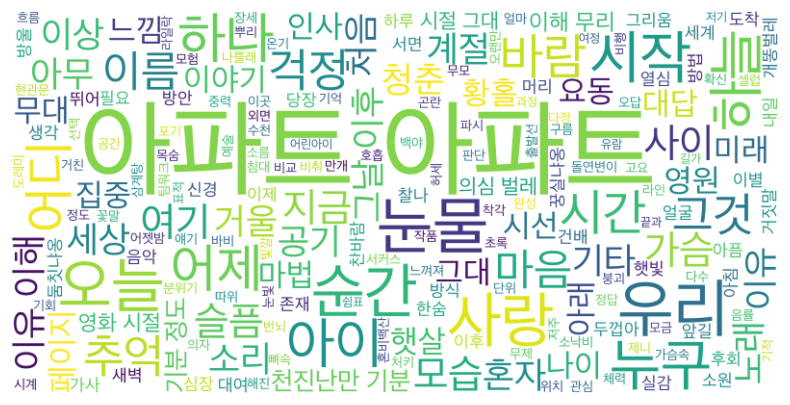

In [23]:

# 7. 단어 구름 시각화
def generate_wordcloud(text):
    wordcloud = WordCloud(width=800, height=400, 
                         background_color='white',
                         font_path='/System/Library/Fonts/AppleSDGothicNeo.ttc'  # macOS 한글 폰트 경로
                        ).generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

print("\n6. 단어 구름 생성 중...")
all_nouns = ' '.join(df['nouns'])
generate_wordcloud(all_nouns)

In [ ]:

# 8. 간단한 검색 엔진 구현
class SimpleSearchEngine:
    def __init__(self, df, tfidf_matrix, vectorizer):
        self.df = df
        self.tfidf_matrix = tfidf_matrix
        self.vectorizer = vectorizer
    
    def search(self, query, top_n=5):
        # 쿼리 전처리 및 변환
        query = preprocess_text(query)
        query_nouns = get_nouns(query)
        query_vec = self.vectorizer.transform([query_nouns])
        
        # 코사인 유사도 계산
        similarities = cosine_similarity(query_vec, self.tfidf_matrix).flatten()
        
        # 상위 N개 결과 반환
        top_indices = similarities.argsort()[-top_n:][::-1]
        
        results = []
        for idx in top_indices:
            results.append({
                'title': self.df.iloc[idx]['title'],
                'artist': self.df.iloc[idx]['artist'],
                'similarity': f"{similarities[idx]:.2%}",
                'lyrics_preview': self.df.iloc[idx]['lyrics'][:100] + '...'
            })
        
        return pd.DataFrame(results)


In [27]:

# 9. 검색 엔진 초기화 및 테스트
print("\n7. 검색 엔진 초기화 중...")
search_engine = SimpleSearchEngine(df, tfidf_matrix, tfidf_vectorizer)

# 테스트 검색
search_words = "제니"
print(f"\n테스트 검색: {search_words}")
results = search_engine.search(search_words)
print("\n검색 결과:")
print(results[['title', 'artist', 'similarity']])



7. 검색 엔진 초기화 중...

테스트 검색: 제니

검색 결과:
             title                   artist similarity
0      like JENNIE              제니 (JENNIE)     33.72%
1    한 페이지가 될 수 있게              DAY6 (데이식스)      0.00%
2  LIKE YOU BETTER                   프로미스나인      0.00%
3         Soda Pop  KPop Demon Hunters Cast      0.00%
4           FAMOUS           ALLDAY PROJECT      0.00%
